# Smoothing Ordered Categorical Variables

Insurance pricing data often arrives with continuous variables already binned into
ordered categories — age bands, mileage bands, risk tiers. A plain categorical
(one-hot) GLM estimates a free parameter per bin, which can be noisy. If we
believe the underlying effect is smooth, we can exploit the ordering by fitting a
spline on the numeric rank of the categories instead.

`OrderedCategorical` wraps this workflow: you pass the ordered labels, choose a
spline type, and get smoothed per-level relativities with SEs.

This notebook demonstrates:

1. **`OrderedCategorical`** — fit B-spline and cubic regression spline models
2. **Raw `Categorical`** — the unconstrained baseline for comparison
3. **Diagnostic overlay** — smoothed vs raw relativities on one plot
4. **Boundary behaviour** — how B-spline and cubic regression differ at the edges

We use the local French MTPL2 frequency parquet when available and fall back to
`fetch_openml` otherwise.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

from superglm import Categorical, OrderedCategorical, Poisson, SuperGLM
from superglm.plotting.common import (
    _EXP_EDGE,
    _EXP_EDGE_LW,
    _EXP_FILL,
    _REF_COLOR,
    _REF_LW,
)

z = norm.ppf(0.975)

## 1. Data preparation

We bin `DrivAge` into 18 ordered bands of 3–5 years each, simulating the
kind of pre-binned variable you'd receive from underwriting or a third-party
data provider.

In [2]:
from sklearn.datasets import fetch_openml

DATA_PATH = Path("../../data/freMTPL2freq.parquet")

if DATA_PATH.exists():
    df = pd.read_parquet(DATA_PATH)
else:
    df = fetch_openml(data_id=41214, as_frame=True, parser="auto").frame
df["ClaimNb"] = df["ClaimNb"].astype(float).clip(upper=4)
df["Exposure"] = df["Exposure"].astype(float).clip(lower=0.01)
df["DrivAge"] = df["DrivAge"].astype(float).clip(18, 90)

y = (df["ClaimNb"] / df["Exposure"]).to_numpy(dtype=float)
exposure = df["Exposure"].to_numpy(dtype=float)

# 18 ordered age bins (3-5 year width)
edges = [18, 21, 25, 29, 33, 37, 41, 45, 49, 53, 57, 61, 65, 69, 73, 77, 81, 85, 91]
labels = []
for i in range(len(edges) - 1):
    hi = edges[i + 1] - 1 if i < len(edges) - 2 else 90
    labels.append(f"{edges[i]}-{hi}")

n_levels = len(labels)

df["AgeBin"] = pd.cut(
    df["DrivAge"],
    bins=edges,
    labels=labels,
    right=False,
    include_lowest=True,
).astype(str)

print(f"{n_levels} bins from {labels[0]} to {labels[-1]}, {len(df):,} rows")
df[["DrivAge", "AgeBin"]].head(10)

18 bins from 18-20 to 85-90, 678,013 rows


,DrivAge,AgeBin
0,55.0,53-56
1,55.0,53-56
2,52.0,49-52
3,46.0,45-48
4,46.0,45-48
5,38.0,37-40
6,38.0,37-40
7,33.0,33-36
8,33.0,33-36
9,41.0,41-44


## 2. Three models

We fit three Poisson GLMs on the same binned data:

| Model | Feature | What it does |
|-------|---------|-------------|
| **B-spline** | `OrderedCategorical(kind="bs")` | Maps bins to 0–1 rank, fits a B-spline with 2nd-difference penalty |
| **Cubic regression** | `OrderedCategorical(kind="cr")` | Same rank mapping, but integrated f'' penalty + f''=0 at boundaries |
| **Raw OHE** | `Categorical` | One free parameter per bin — the unconstrained baseline |

In [3]:
k = 8

# B-spline
m_bs = SuperGLM(
    family=Poisson(),
    features={"AgeBin": OrderedCategorical(order=labels, basis="spline", kind="bs", n_knots=k)},
    discrete=True,
)
m_bs.fit_reml(df[["AgeBin"]], y, sample_weight=exposure)
ti_bs = m_bs.term_inference("AgeBin")
print(f"B-spline:          edf = {ti_bs.edf:.1f}")

# Cubic regression spline
m_cr = SuperGLM(
    family=Poisson(),
    features={"AgeBin": OrderedCategorical(order=labels, basis="spline", kind="cr", n_knots=k)},
    discrete=True,
)
m_cr.fit_reml(df[["AgeBin"]], y, sample_weight=exposure)
ti_cr = m_cr.term_inference("AgeBin")
print(f"Cubic regression:  edf = {ti_cr.edf:.1f}")

# Raw categorical (OHE)
m_ohe = SuperGLM(
    family=Poisson(),
    features={"AgeBin": Categorical(base="most_exposed")},
    discrete=True,
)
m_ohe.fit(df[["AgeBin"]], y, sample_weight=exposure)
ti_ohe = m_ohe.term_inference("AgeBin")
print(f"Raw categorical:   {len(ti_ohe.levels)} levels")

B-spline:          edf = 10.4


Cubic regression:  edf = 8.4


Raw categorical:   18 levels


## 3. Per-level relativities

All three models produce per-level relativities through the same API.
`OrderedCategorical` returns `kind="categorical"` with smoothed values
at the K level positions.

In [4]:
rels_bs = m_bs.relativities(with_se=True)["AgeBin"]
rels_cr = m_cr.relativities(with_se=True)["AgeBin"]
rels_ohe = m_ohe.relativities(with_se=True)["AgeBin"]

print("B-spline relativities:")
rels_bs

B-spline relativities:


,level,relativity,log_relativity,se_log_relativity
0,18-20,2.348407,0.853737,0.038837
1,21-24,1.654949,0.503770,0.022517
2,25-28,1.090184,0.086346,0.016823
3,29-32,0.882318,-0.125202,0.012081
4,33-36,0.836948,-0.177994,0.013560
5,37-40,0.859850,-0.150997,0.010520
6,41-44,0.932064,-0.070354,0.012109
7,45-48,1.012728,0.012648,0.010811
8,49-52,1.000924,0.000923,0.011075
9,53-56,0.906786,-0.097848,0.013047


## 4. Diagnostic plot — smoothed vs raw

To overlay spline and OHE relativities on the same axes, we re-center
everything to geometric mean = 1 over the K levels. This is necessary
because the spline uses sum-to-zero centering (SSP identifiability) while
the categorical uses base-level centering — different reference points.

The re-centering is simple: `exp(log_rel - mean(log_rel))` for each model,
applied consistently to both the level dots and the smooth curve.

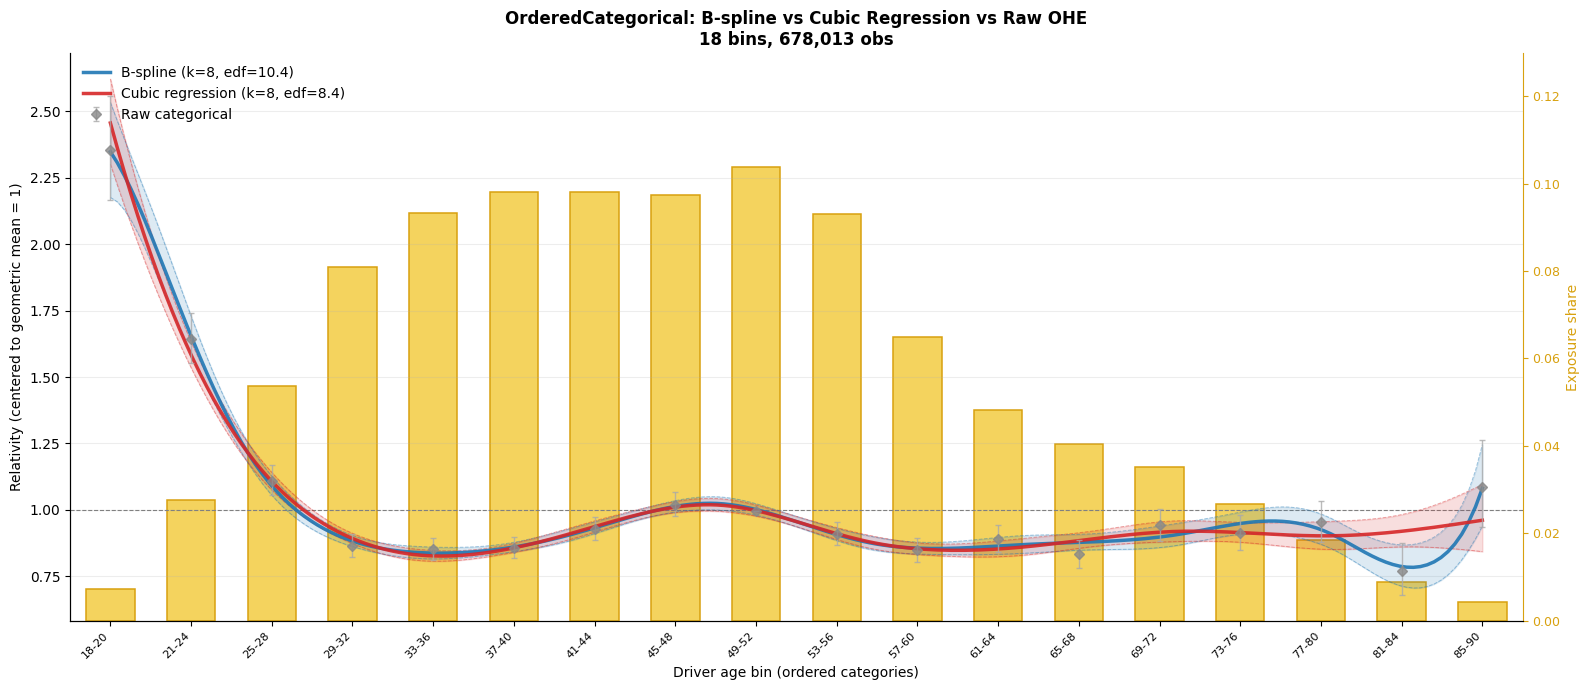

In [5]:
# Exposure share per bin
exp_by_level = pd.DataFrame({"level": df["AgeBin"], "exp": exposure}).groupby("level")["exp"].sum()
exp_share = exp_by_level.reindex(labels, fill_value=0).values.copy()
exp_share /= exp_share.sum()

x_pos = np.arange(n_levels, dtype=float)

fig, ax = plt.subplots(figsize=(16, 7))

# Exposure bars
ax2 = ax.twinx()
ax2.bar(
    x_pos,
    exp_share,
    width=0.6,
    color=_EXP_FILL,
    edgecolor=_EXP_EDGE,
    linewidth=_EXP_EDGE_LW,
    alpha=1.0,
    zorder=0,
    label="Exposure share",
)
ax2.set_ylabel("Exposure share", color=_EXP_EDGE)
ax2.set_ylim(0, max(exp_share) * 1.25)
ax2.tick_params(axis="y", colors=_EXP_EDGE, labelsize=9)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_color(_EXP_EDGE)
ax2.grid(False)
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)

ax.axhline(1.0, color=_REF_COLOR, linewidth=_REF_LW, linestyle="--", zorder=0)


# Helper: plot smooth curve + CI, re-centered to geometric mean = 1
def plot_smooth(ax, ti, color, label):
    # Re-center: shift so geometric mean of level relativities = 1
    level_log_rels = np.asarray(ti.log_relativity, dtype=float)
    shift = level_log_rels.mean()

    curve = ti.smooth_curve
    x_fine = np.linspace(x_pos[0], x_pos[-1], len(curve.x))
    curve_rel = np.exp(np.asarray(curve.log_relativity, dtype=float) - shift)

    # CI band (also shifted)
    if curve.se_log_relativity is not None:
        se = np.asarray(curve.se_log_relativity, dtype=float)
        curve_log = np.asarray(curve.log_relativity, dtype=float) - shift
        ci_lo = np.exp(curve_log - z * se)
        ci_hi = np.exp(curve_log + z * se)
        ax.fill_between(x_fine, ci_lo, ci_hi, color=color, alpha=0.15, zorder=2)
        ax.plot(x_fine, ci_lo, color=color, linestyle="--", linewidth=0.7, alpha=0.4, zorder=3)
        ax.plot(x_fine, ci_hi, color=color, linestyle="--", linewidth=0.7, alpha=0.4, zorder=3)

    ax.plot(x_fine, curve_rel, color=color, linewidth=2.5, alpha=0.9, label=label, zorder=5)


plot_smooth(ax, ti_bs, "#1f77b4", f"B-spline (k={k}, edf={ti_bs.edf:.1f})")
plot_smooth(ax, ti_cr, "#d62728", f"Cubic regression (k={k}, edf={ti_cr.edf:.1f})")

# Raw OHE scatter with error bars (also re-centered to geometric mean = 1)
ohe_log_rels = np.asarray(ti_ohe.log_relativity, dtype=float)
ohe_shift = ohe_log_rels.mean()
ohe_rel = np.exp(ohe_log_rels - ohe_shift)
ohe_se = (
    np.asarray(ti_ohe.se_log_relativity, dtype=float)
    if ti_ohe.se_log_relativity is not None
    else None
)
if ohe_se is not None:
    ohe_ci_lo = np.exp((ohe_log_rels - ohe_shift) - z * ohe_se)
    ohe_ci_hi = np.exp((ohe_log_rels - ohe_shift) + z * ohe_se)
    yerr = [ohe_rel - ohe_ci_lo, ohe_ci_hi - ohe_rel]
else:
    yerr = None
ax.errorbar(
    x_pos,
    ohe_rel,
    yerr=yerr,
    fmt="D",
    color="#888888",
    markersize=5,
    alpha=0.8,
    ecolor="#aaaaaa",
    elinewidth=1.0,
    capsize=2,
    label="Raw categorical",
    zorder=6,
)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_xlim(-0.5, n_levels - 0.5)
ax.set_xlabel("Driver age bin (ordered categories)")
ax.set_ylabel("Relativity (centered to geometric mean = 1)")
ax.set_title(
    f"OrderedCategorical: B-spline vs Cubic Regression vs Raw OHE\n"
    f"{n_levels} bins, {len(df):,} obs",
    fontweight="bold",
)
ax.grid(alpha=0.22, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

## 5. Key takeaways

| | Raw Categorical | OrderedCategorical (spline) |
|---|---|---|
| **Parameters** | K-1 free | ~edf (REML-selected) |
| **Assumption** | None — each bin independent | Smooth underlying effect |
| **Noisy tails** | Wide CIs, erratic | Borrows strength from neighbours |
| **Boundary** | N/A | `kind="bs"`: free curvature; `kind="cr"`: forced linear |
| **Use case** | Unordered categories (region, vehicle type) | Ordered/binned continuous variables |

The spline doesn't change the *model* — it changes the *parameterisation*.
Instead of K-1 free parameters, you get a smooth curve controlled by a
penalty, with REML choosing how much to smooth. The raw OHE estimates
serve as a diagnostic: if the spline diverges substantially from the OHE
dots, the smoothness assumption may not hold.